Using Colab cache for faster access to the 'nyc-flights-2013' dataset.
Path to dataset files: /kaggle/input/nyc-flights-2013

Files in dataset:
['nyc_weather.csv', 'nyc_airlines.csv', 'nyc_flights.csv', 'nyc_planes.csv', 'nyc_airports.csv']

Dataset loaded successfully!

=== TASK A1: DATASET OVERVIEW ===

Structure of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10 

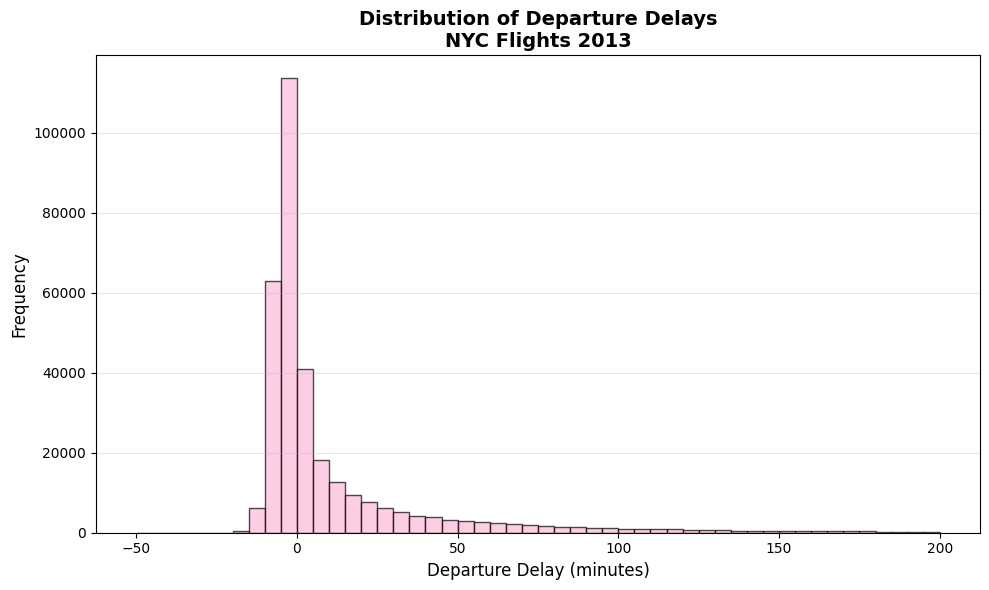


=== TASK B2: DELAYS BY AIRLINE ===



/tmp/ipython-input-156565077.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights_clean, x='carrier', y='dep_delay', palette='Set2')


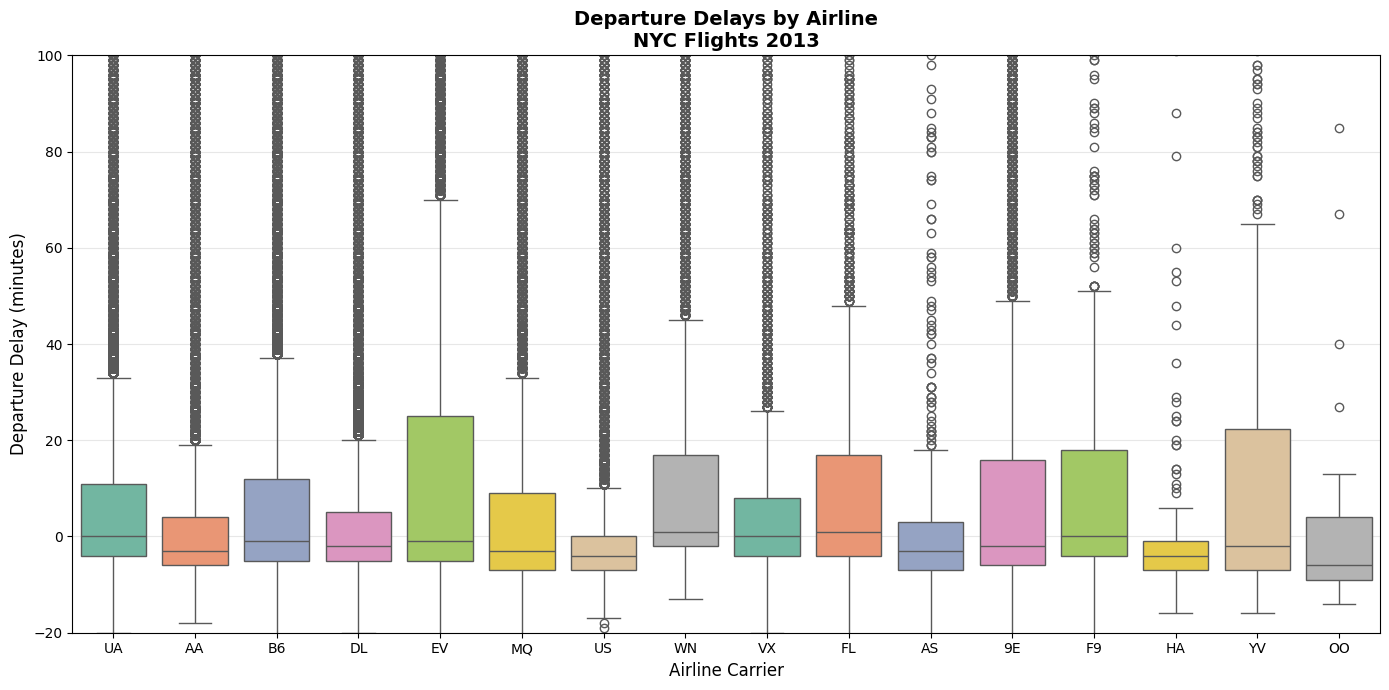


Airlines ranked by variability (standard deviation):
         mean_delay  std_delay  iqr_delay
carrier                                  
HA         4.900585  74.109901       6.00
F9        20.201175  58.404339      22.00
FL        18.605984  52.491059      21.00
YV        18.898897  49.164838      29.25
EV        19.838929  46.446174      30.00
9E        16.439574  45.487513      22.00
VX        12.756646  44.016255      12.00
WN        17.661657  43.237454      19.00
OO        12.586207  43.065994      13.00
DL         9.223950  39.656296      10.00
MQ        10.445381  39.025198      16.00
B6        12.967548  38.380215      17.00
AA         8.569130  37.365267      10.00
UA        12.016908  35.547921      15.00
AS         5.830748  31.426798      10.00
US         3.744693  27.939106       7.00

--- Interpretation ---
The airline with the greatest variability is: HA
Standard deviation: 74.11 minutes
This airline shows the most inconsistent departure delays.

=== TASK B3: DISTANCE v

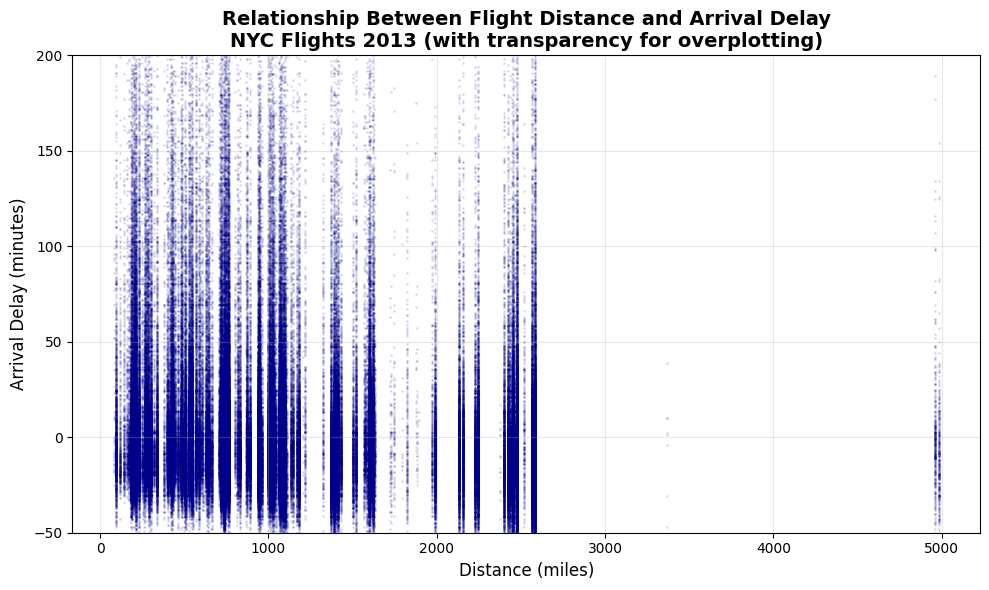

Scatter plot created successfully!

=== TASK C1: SUMMARY STATISTICS ===

Departure Delay Statistics:
  Mean:   12.56 minutes
  Median: -2.00 minutes
  Difference: 14.56 minutes

Arrival Delay Statistics:
  Mean:   6.90 minutes
  Median: -5.00 minutes
  Difference: 11.90 minutes

--- Explanation ---
The mean and median differ because the delay distributions are right-skewed.
Most flights have small delays or are early (negative delays), but some flights
have very large delays (outliers), which pull the mean higher than the median.
The median is more representative of a 'typical' flight delay since it is not
affected by extreme values. This right-skewed distribution is common in delay
data where most events are normal but a few are exceptional.

=== TASK C2: INSIGHTS ===

Based on the analysis and visualizations:

Flight delays in NYC are mostly caused by which airline you pick and airport traffic, not by how many miles you fly. 
Some airlines are much more reliable than others, because 

In [8]:
# Using Kaggle Dataset

# Install and import required packages
!pip install kagglehub pandas numpy matplotlib seaborn -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download latest version from Kaggle
path = kagglehub.dataset_download("aephidayatuloh/nyc-flights-2013")
print("Path to dataset files:", path)

# List files in the directory
print("\nFiles in dataset:")
print(os.listdir(path))

# Load the flights dataset
# The dataset contains multiple CSV files, we need nyc_flights.csv
flights = pd.read_csv(os.path.join(path, 'nyc_flights.csv'))

print("\nDataset loaded successfully!")

# ============================================================================
# PART A: DATA UNDERSTANDING & PREPARATION (10 points)
# ============================================================================

# Task A1: Dataset Overview (4 points)
# ------------------------------------

print("\n" + "="*70)
print("=== TASK A1: DATASET OVERVIEW ===")
print("="*70 + "\n")

# Display structure
print("Structure of the dataset:")
print(flights.info())

print("\n\nDimensions of the dataset:")
print(f"Shape: {flights.shape}")

print("\n\nFirst few rows:")
print(flights.head())

# Identify observations and variables
n_obs, n_vars = flights.shape

print("\n--- Summary ---")
print(f"Number of observations: {n_obs}")
print(f"Number of variables: {n_vars}")

# Identify variable types
print("\nVariable Types:")
print(f"Numeric variables: {flights.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical/Object variables: {flights.select_dtypes(include=['object']).shape[1]}")

print("\nData types of each column:")
print(flights.dtypes)

# Task A2: Data Cleaning (6 points)
# ----------------------------------

print("\n" + "="*70)
print("=== TASK A2: DATA CLEANING ===")
print("="*70 + "\n")

# Identify missing values
print(f"Missing values in dep_delay: {flights['dep_delay'].isna().sum()}")
print(f"Missing values in arr_delay: {flights['arr_delay'].isna().sum()}")

# Create cleaned dataset
flights_clean = flights.dropna(subset=['dep_delay', 'arr_delay'])

print(f"\nOriginal dataset size: {len(flights)} rows")
print(f"Cleaned dataset size: {len(flights_clean)} rows")
print(f"Rows removed: {len(flights) - len(flights_clean)}")

# ============================================================================
# PART B: DATA VISUALIZATION (12 points)
# ============================================================================

# Task B1: Distribution of Departure Delays (4 points)
# -----------------------------------------------------

print("\n" + "="*70)
print("=== TASK B1: DEPARTURE DELAY DISTRIBUTION ===")
print("="*70 + "\n")

plt.figure(figsize=(10, 6))
plt.hist(flights_clean['dep_delay'], bins=50, color='#FDB8D9',
         edgecolor='black', alpha=0.7, range=(-50, 200))
plt.xlabel('Departure Delay (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Departure Delays\nNYC Flights 2013', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Task B2: Flight Delays by Airline (4 points)
# ---------------------------------------------

print("\n" + "="*70)
print("=== TASK B2: DELAYS BY AIRLINE ===")
print("="*70 + "\n")

plt.figure(figsize=(14, 7))
sns.boxplot(data=flights_clean, x='carrier', y='dep_delay', palette='Set2')
plt.xlabel('Airline Carrier', fontsize=12)
plt.ylabel('Departure Delay (minutes)', fontsize=12)
plt.title('Departure Delays by Airline\nNYC Flights 2013', fontsize=14, fontweight='bold')
plt.ylim(-20, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate variability by carrier
variability = flights_clean.groupby('carrier')['dep_delay'].agg([
    ('mean_delay', 'mean'),
    ('std_delay', 'std'),
    ('iqr_delay', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).sort_values('std_delay', ascending=False)

print("\nAirlines ranked by variability (standard deviation):")
print(variability)

print("\n--- Interpretation ---")
print(f"The airline with the greatest variability is: {variability.index[0]}")
print(f"Standard deviation: {variability.iloc[0]['std_delay']:.2f} minutes")
print("This airline shows the most inconsistent departure delays.")

# Task B3: Relationship Between Distance and Arrival Delay (4 points)
# --------------------------------------------------------------------

print("\n" + "="*70)
print("=== TASK B3: DISTANCE vs ARRIVAL DELAY ===")
print("="*70 + "\n")

plt.figure(figsize=(10, 6))
plt.scatter(flights_clean['distance'], flights_clean['arr_delay'],
           alpha=0.1, color='darkblue', s=1)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Arrival Delay (minutes)', fontsize=12)
plt.title('Relationship Between Flight Distance and Arrival Delay\nNYC Flights 2013 (with transparency for overplotting)',
         fontsize=14, fontweight='bold')
plt.ylim(-50, 200)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Scatter plot created successfully!")

# ============================================================================
# PART C: INTERPRETATION & INSIGHTS (8 points)
# ============================================================================

# Task C1: Summary Statistics (4 points)
# ---------------------------------------

print("\n" + "="*70)
print("=== TASK C1: SUMMARY STATISTICS ===")
print("="*70 + "\n")

# Calculate statistics
mean_dep = flights_clean['dep_delay'].mean()
median_dep = flights_clean['dep_delay'].median()
mean_arr = flights_clean['arr_delay'].mean()
median_arr = flights_clean['arr_delay'].median()

print("Departure Delay Statistics:")
print(f"  Mean:   {mean_dep:.2f} minutes")
print(f"  Median: {median_dep:.2f} minutes")
print(f"  Difference: {mean_dep - median_dep:.2f} minutes")

print("\nArrival Delay Statistics:")
print(f"  Mean:   {mean_arr:.2f} minutes")
print(f"  Median: {median_arr:.2f} minutes")
print(f"  Difference: {mean_arr - median_arr:.2f} minutes")

print("\n--- Explanation ---")
print("The mean and median differ because the delay distributions are right-skewed.")
print("Most flights have small delays or are early (negative delays), but some flights")
print("have very large delays (outliers), which pull the mean higher than the median.")
print("The median is more representative of a 'typical' flight delay since it is not")
print("affected by extreme values. This right-skewed distribution is common in delay")
print("data where most events are normal but a few are exceptional.")

# Task C2: Insight Question (4 points)
# -------------------------------------

print("\n" + "="*70)
print("=== TASK C2: INSIGHTS ===")
print("="*70 + "\n")

print("Based on the analysis and visualizations:\n")
print("Flight delays in NYC are mostly caused by which airline you pick and airport traffic, not by how many miles you fly. \nSome airlines are much more reliable than others, because delays are common even on short trips, the problem seems to be congestion on the ground in NYC. \nThe average (mean) delay is significantly higher than the middle (median) delay because a few extremely long delays skew the data, \nmaking the average look worse than what most passengers actually experience.")

print("\n" + "="*70)
print("=== SUMMARY ===")
print("="*70)

# Additional summary for your report
print(f"Total flights analyzed: {len(flights_clean):,}")
print(f"Average departure delay: {mean_dep:.2f} minutes")
print(f"Average arrival delay: {mean_arr:.2f} minutes")
print(f"Most variable airline: {variability.index[0]} (SD: {variability.iloc[0]['std_delay']:.2f} min)")
print(f"Least variable airline: {variability.index[-1]} (SD: {variability.iloc[-1]['std_delay']:.2f} min)")